

<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_09_nn_zeroV1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 9: Red neuronal

In [40]:
import pandas as pd
import scipy as sc
import numpy as np
import h5py
import matplotlib.pylab as plt

In [41]:
data_train= "train_catvnoncat.h5"
train_dataset = h5py.File(data_train, "r") # No sé donde ubicar este archivo, no lo veo en ninguna parte del repo. 
# find . -name "train_catvnoncat.h5 NO RETORNA NADA. Decidí buscarlo en internet para continuar y encontré uno con el mismo
# nombre en el repositorio: https://github.com/JudasDie/deeplearning.ai/blob/master/Improving%20Deep%20Neural%20Networks/Week1/Regularization/datasets

data_test= "test_catvnoncat.h5"
test_dataset = h5py.File(data_test, "r")

In [42]:
train_dataset.keys()

<KeysViewHDF5 ['list_classes', 'train_set_x', 'train_set_y']>

In [43]:
# Read the data
xtrain_classes, xtrain, train_label =\
train_dataset["list_classes"],train_dataset["train_set_x"],train_dataset["train_set_y"]

test_classes, xtest,test_label =\
test_dataset["list_classes"],test_dataset["test_set_x"],test_dataset["test_set_y"]


In [44]:
np.shape(xtrain)

(209, 64, 64, 3)

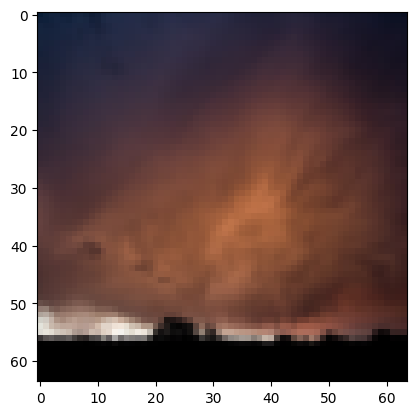

In [45]:
plt.imshow(xtrain[208])

In [46]:
np.shape(xtrain[0])

(64, 64, 3)

In [47]:
np.reshape(xtrain[0], 64*64*3)

array([17, 31, 56, ...,  0,  0,  0], shape=(12288,), dtype=uint8)

In [48]:

xtrain_= np.reshape(xtrain,(209, 64*64*3))/255
xtest_ = np.reshape(xtest,(50, 64*64*3))/255

In [49]:
len(xtrain_[208])

12288

In [50]:
64*64*3

12288

Construyamos una red neuronal con una capa de entrada, una capa de salida con una red y L-1 redes ocultas.

# Con m datos de entrenamientos.

Para $m$ datos de entrenamiento, las expresión anteriores pueden ser resumidas en las siguientes ecuaciones



\begin{equation}
\begin{bmatrix}
z_1^{(0)}  &z_1^{(1)} & .&.& .&z_1^{(m)}\\
z_2^{(0)}  &z_2^{(1)} &. &.&  .&z_2^{(m)}\\
.          & .        &. & &   &.      \\
.          & .        &  &. &   &.      \\
.          & .        &  &  & .&      \\
z_{n^{[l]}}^{(0)}&z_{n^{[l]}}^{(1)} & . & .& .& z_{n^{[l]}}^{(m)}        \\
\end{bmatrix}^{[l]}=
\begin{bmatrix}
\theta_{11} & \theta_{12} & . & .& .& \theta_{1n^{[l-1]}}\\
\theta_{21} & \theta_{22} & . & .& .& \theta_{2n^{[l-1]}}\\
. & .  & . &   & & .\\
. & .  &   & . & & .\\
. & .  &   &  & .& .\\
\theta_{n^{[l]}1} & \theta_{n^{[l]}2} & . & .& .& \theta_{n^{[l]}n^{[l-1]}}\\
\end{bmatrix}^{[l]}_{n^{[l]} \times n^{[l-1]}}
\begin{bmatrix}
a_1^{(0)}  &a_1^{(1)} & .&.& .&a_1^{(m)}\\
a_2^{(0)}  &a_2^{(1)} &. &.&  .&a_2^{(m)}\\
.          & .        &. & &   &.      \\
.          & .        &  &. &   &.      \\
.          & .        &  &  & .&      \\
a_{n^{[L-1]}}^{(0)}&a_{n^{[L-1]}}^{(1)} & . & .& .& a_{n^{[L-1]}}^{(m)}        \\
\end{bmatrix}^{[l-1]} +
\begin{bmatrix}
b_1 \\
b_2 \\
. \\
. \\
. \\
b_{n^{[l]}}\\
\end{bmatrix}^{[l]}
\end{equation}


Escrito de una formas mas compacta tenemos que:


\begin{equation}
[ \vec{Z}^{[l](0)},\vec{Z}^{[l](1)},...,\vec{Z}^{[l](m)}  ]= \Theta^{[l]} [\vec{A}^{[l-1](0)},\vec{A}^{[l-1](1)},...,\vec{A}^{[l-1](m)} ]+ \vec{b}^{[l]}
\end{equation}

Aplicando la funcion de activación:

\begin{equation}
[\vec{A}^{[l](0)},\vec{A}^{[l](1)},...,\vec{A}^{[l](m)} ]=f([\vec{Z}^{[l](0)},\vec{Z}^{[l](1)},...,\vec{Z}^{[l](m)}  ])
\end{equation}

Las dimensiones de las expresiones anteriores, pueden ser resumidas en lo siguiente:

$\mathrm{dim(\vec{\cal{Z}}^{[l]})}=n^{[l]}\times m $

$\mathrm{dim(\vec{\Theta}^{[l]})}=n^{[l]}\times n^{[l-1]}$

$\mathrm{dim(\vec{\cal{A}}^{[l]})}=n^{[l-1]}\times m $

$\mathrm{dim(\vec{b}^{[l]})}=n^{[l]}$




## Topología de la red.

1. Construir un clase  que permita definir una red neuronal con la topología
deseada y la función de activación para cada capa, para ello deberá construir una funcion Topology con el número de capas de la red neuronal :

Topology = [n_x, n_h1, n_h2, n_h3, ...,n_y]

En este caso:
- $n^{[0]}=n_x$ seran los valores de entradas de la capa de entrada
- $n^{[1]}=n_{h1}$ Primera capa oculta de la red neuronal
- $n^{[2]}=n_{h2}$ Segunda capa oculta de la red neuronal

.

.

.


- $n^{[l]}=n_{hl}$ Segunda capa oculta de la red neuronal
.

.

.

- $n^{[L]}=n_{y}$ Segunda capa oculta de la red neuronal

donde

- $\mathrm{n_x}$: valores de entrada
- $\mathrm{n_{h1}}$: hidden layer 1
- $\mathrm{n_{h2}}$: hidden layer 2
- $\mathrm{n_y}$: last layer

- $n^{[L]}=n_{y}$ Segunda capa oculta de la red neuronal


También definir una lista con las funciones de activaciones para cada capa.


activation=[None, relu, relu, relu, ...,sigmoid]

  


a. Cada unas de las capas deberá tener los parámetros de inicialización de manera aleatoria:


La matriz de parametros para cada capa debera tener:


$\mathrm{dim(\vec{b}^{[l]})}=n^{[l]}$

$\mathrm{dim(\vec{\Theta}^{[l]})}=n^{[l]}\times n^{[l-1]}$

Lo anteriores parametros deberán estar en el constructor de la clase.


b. Construya un metodo llamado output cuya salida serán los valores de Z y A


$\mathrm{dim(\vec{\cal{A}}^{[l]})}=n^{[l-1]}\times m $

$\mathrm{dim(\vec{\cal{Z}}^{[l]})}=n^{[l]}\times m $.

In [51]:
import numpy as np


def act_function(Z: np.ndarray, activation: str) -> tuple:
    """
    Applies an activation function element-wise and returns its derivative.

    The derivative dA/dZ is computed alongside A because the backward pass
    needs it — computing both together avoids a redundant forward re-evaluation.

    Args:
        Z (np.ndarray): Pre-activation matrix, shape (n_units, m).
        activation (str): One of 'sigmoid', 'relu', 'tanh', 'linear'.

    Returns:
        tuple[np.ndarray, np.ndarray]: (A, dAdZ) — activated output and
            element-wise derivative w.r.t. Z, both shape (n_units, m).

    Raises:
        ValueError: If the activation name is not recognized.
    """
    if activation == "sigmoid":
        A = 1 / (1 + np.exp(-Z))
        dAdZ = A * (1 - A)

    elif activation == "relu":
        A = np.maximum(0, Z)
        dAdZ = (Z > 0).astype(float)

    elif activation == "tanh":
        A = np.tanh(Z)
        dAdZ = 1 - A ** 2

    elif activation == "linear":
        A = Z.copy()
        dAdZ = np.ones_like(Z)

    else:
        raise ValueError(
            f"Unknown activation '{activation}'. "
            "Choose from: 'sigmoid', 'relu', 'tanh', 'linear'."
        )

    return A, dAdZ

In [ ]:
class Layer:
    """
    Single fully-connected layer of a neural network.

    Weights are initialized with He initialization (scale = sqrt(2 / n_prev)),
    which keeps variance stable across layers with ReLU activations and prevents
    vanishing/exploding gradients from the start.

    Biases are initialized to zero — symmetry breaking is handled by the random
    weights, so zero biases are sufficient and standard.

    Args:
        n_units (int): Number of neurons in this layer  (n^[l]).
        n_prev (int): Number of neurons in the previous layer (n^[l-1]).
        activation (str): One of 'sigmoid', 'relu', 'tanh', 'linear'.
    """

    def __init__(self, n_units: int, n_prev: int, activation: str):
        # He init: var(W) = 2/n_prev keeps activations in a healthy range for ReLU
        self._theta = np.random.randn(n_units, n_prev) * np.sqrt(2 / n_prev)
        self._b = np.zeros((n_units, 1))
        self._activation = activation
        self._n_units = n_units

        # Forward-pass cache — populated by .forward(), consumed by backward_pass()
        self.Z = None
        self.A = None
        self.A_prev = None
        self.dAdZ = None

        # Backward-pass cache — populated by backward_pass(), consumed by update_params()
        self.dTheta = None
        self.db = None

    def forward(self, A_prev: np.ndarray) -> np.ndarray:
        """
        Computes the forward pass for this layer.

        Implements:
            Z^[l] = Theta^[l] @ A^[l-1] + b^[l]
            A^[l] = f(Z^[l])

        The intermediate values Z, A, A_prev, and dAdZ are stored as instance
        attributes so the backward pass can access them without recomputing.

        Args:
            A_prev (np.ndarray): Activations from the previous layer, shape (n_prev, m).

        Returns:
            np.ndarray: Activated output A, shape (n_units, m).
        """
        self.A_prev = A_prev
        self.Z = self._theta @ A_prev + self._b
        self.A, self.dAdZ = act_function(self.Z, self._activation)
        return self.A

    @property
    def theta(self) -> np.ndarray:
        """Weight matrix Theta, shape (n_units, n_prev)."""
        return self._theta

    @property
    def b(self) -> np.ndarray:
        """Bias vector b, shape (n_units, 1)."""
        return self._b

    @property
    def activation(self) -> str:
        """Name of the activation function for this layer."""
        return self._activation

    @property
    def n_units(self) -> int:
        """Number of neurons in this layer."""
        return self._n_units

In [53]:
# Quick sanity check for Layer
layer = Layer(n_units=3, n_prev=4, activation="relu")

print(f"theta shape : {layer.theta.shape}")   # expected: (3, 4)
print(f"b shape     : {layer.b.shape}")        # expected: (3, 1)
print(f"activation  : {layer.activation}")

A_fake = np.random.randn(4, 5)               # fake batch: 4 features, 5 samples
A_out = layer.forward(A_fake)
print(f"A_out shape : {A_out.shape}")          # expected: (3, 5)

theta shape : (3, 4)
b shape     : (3, 1)
activation  : relu
A_out shape : (3, 5)


In [54]:
# Manually wiring layers for topology [10, 3, 4, 6, 1]
# This shows what NeuralNetwork automates — see the implementation below
topology = [10, 3, 4, 6, 1]

l1 = Layer(n_units=3, n_prev=10, activation="relu")
l2 = Layer(n_units=4, n_prev=3,  activation="relu")
l3 = Layer(n_units=6, n_prev=4,  activation="relu")
l4 = Layer(n_units=1, n_prev=6,  activation="sigmoid")

In [55]:
A0 = xtrain_.T

In [56]:
# Forward pass through the first layer (real data)
# l1 above has n_prev=10 (toy topology) — incompatible with the actual input.
# To run .forward() on xtrain_, the layer must have n_prev=12288.
A0 = xtrain_.T                               # shape: (12288, 209)
l1_real = Layer(n_units=3, n_prev=12288, activation="relu")
A1 = l1_real.forward(A0)
print(f"A0 shape: {A0.shape}")               # (12288, 209)
print(f"A1 shape: {A1.shape}")               # (3, 209)

A0 shape: (12288, 209)
A1 shape: (3, 209)


Se sugiere para cada capa emplear programación orientada a objetos definida de la siguiente manera:

```
class layer_nn():
  def __init__(self, act_fun, nlayer_present, nlayer_before):
    self.theta = 2*np.random.random((nlayer_present, nlayer_before)) - 1
    self.B = 2*np.random.random((nlayer_present,1)) - 1
    self.act_fun = act_fun

  def output(self, Z, A):
    self.Z = Z
    self.A = A



def act_function(x, activation):
  if activation=="sigmoid":
    f = lambda x: 1/(1+np.exp(-x))
    fp = f(x)*(1-f(x))
    return f, fp
  
  elif activation == "tanh":
    f = lambda x: np.tanh
    return tanh
  else :
    return 0
```

In [59]:
# Código hecho con ayuda de CLAUDE CODE
class NeuralNetwork:
    """
    Fully-connected neural network built layer by layer, similar to Keras Sequential.

    Takes a topology list and an activation list, builds the corresponding Layer
    objects, and exposes methods to inspect the architecture and access parameters.

    Args:
        topology (list[int]): Number of units per layer, including the input.
            Example: [12288, 20, 7, 5, 1]
            topology[0] is the input dimension (no learnable parameters).
            topology[1:] define the hidden and output layers.
        activations (list[str]): Activation function per computed layer.
            Length must equal len(topology) - 1.
            Example: ['relu', 'relu', 'relu', 'sigmoid']

    Raises:
        ValueError: If len(activations) != len(topology) - 1.

    Example:
        >>> nn = NeuralNetwork([12288, 20, 7, 5, 1], ['relu', 'relu', 'relu', 'sigmoid'])
        >>> nn.summary()
    """

    def __init__(self, topology: list, activations: list):
        if len(activations) != len(topology) - 1:
            raise ValueError(
                f"topology has {len(topology)} entries → needs {len(topology) - 1} "
                f"activations, got {len(activations)}."
            )
        self._topology = topology
        self._activations = activations
        self._layers = [
            Layer(topology[l], topology[l - 1], activations[l - 1])
            for l in range(1, len(topology))
        ]

    def summary(self) -> None:
        """Prints a table describing the network architecture and parameter counts."""
        col = (
            f"{'Layer':>6}  {'n_units':>8}  {'activation':>10}  "
            f"{'Theta shape':>15}  {'b shape':>10}  {'params':>8}"
        )
        sep = "-" * len(col)
        print(col)
        print(sep)
        print(f"{'Input':>6}  {self._topology[0]:>8}  {'—':>10}  {'—':>15}  {'—':>10}  {'—':>8}")
        for idx, layer in enumerate(self._layers, start=1):
            n_params = layer.theta.size + layer.b.size
            print(
                f"{idx:>6}  {layer.n_units:>8}  {layer.activation:>10}  "
                f"{str(layer.theta.shape):>15}  {str(layer.b.shape):>10}  {n_params:>8,}"
            )
        total = sum(l.theta.size + l.b.size for l in self._layers)
        print(sep)
        print(f"Total trainable parameters: {total:,}")

    def get_params(self, layer: int) -> dict:
        """
        Returns parameters for a specific layer (1-indexed).

        Args:
            layer (int): Layer index starting at 1. Layer 1 is the first
                hidden or output layer (not the input).

        Returns:
            dict: {'theta': np.ndarray, 'b': np.ndarray, 'activation': str}

        Raises:
            IndexError: If layer is outside [1, L].
        """
        if layer < 1 or layer > len(self._layers):
            raise IndexError(
                f"Layer must be between 1 and {len(self._layers)}, got {layer}."
            )
        l = self._layers[layer - 1]
        return {"theta": l.theta, "b": l.b, "activation": l.activation}

    def parameters(self) -> dict:
        """
        Returns all parameters indexed by layer number (1-indexed).

        Returns:
            dict[int, dict]: Keys are layer indices 1..L, each value has
                'theta', 'b', and 'activation'.
        """
        return {idx: self.get_params(idx) for idx in range(1, len(self._layers) + 1)}

    def __len__(self) -> int:
        """Number of parameterized layers (input layer is excluded)."""
        return len(self._layers)

    def __repr__(self) -> str:
        return f"NeuralNetwork(topology={self._topology}, activations={self._activations})"

In [60]:
# --- Verification ---
nn = NeuralNetwork(
    topology    = [12288, 20, 7, 5, 1],
    activations = ['relu', 'relu', 'relu', 'sigmoid'],
)
nn.summary()

print()
p1 = nn.get_params(1)
print(f"Layer 1 — theta: {p1['theta'].shape}, b: {p1['b'].shape}, activation: {p1['activation']}")

assert nn.get_params(1)['theta'].shape == (20, 12288), "Layer 1 theta shape mismatch"
assert nn.get_params(1)['b'].shape     == (20, 1),     "Layer 1 b shape mismatch"
assert nn.get_params(4)['theta'].shape == (1, 5),      "Layer 4 theta shape mismatch"
print("\nAll shape assertions passed.")

 Layer   n_units  activation      Theta shape     b shape    params
-------------------------------------------------------------------
 Input     12288           —                —           —         —
     1        20        relu      (20, 12288)     (20, 1)   245,780
     2         7        relu          (7, 20)      (7, 1)       147
     3         5        relu           (5, 7)      (5, 1)        40
     4         1     sigmoid           (1, 5)      (1, 1)         6
-------------------------------------------------------------------
Total trainable parameters: 245,973

Layer 1 — theta: (20, 12288), b: (20, 1), activation: relu

All shape assertions passed.


2. Construir un generalizacion de la red, en el que entrada el valor inicial
y la red neuronal completa arroje la salida y la actualizacion de la red con los parametros deseados:

  ```
  A, nn = forward_pass(A0, nn_red)

 ```

In [61]:
# Código hecho con ayuda de CLAUDE CODE
class NeuralNetwork:
    """
    Fully-connected neural network built layer by layer, similar to Keras Sequential.

    Takes a topology list and an activation list, builds the corresponding Layer
    objects, and exposes methods to inspect the architecture and access parameters.

    Args:
        topology (list[int]): Number of units per layer, including the input.
            Example: [12288, 20, 7, 5, 1]
            topology[0] is the input dimension (no learnable parameters).
            topology[1:] define the hidden and output layers.
        activations (list[str]): Activation function per computed layer.
            Length must equal len(topology) - 1.
            Example: ['relu', 'relu', 'relu', 'sigmoid']

    Raises:
        ValueError: If len(activations) != len(topology) - 1.

    Example:
        >>> nn = NeuralNetwork([12288, 20, 7, 5, 1], ['relu', 'relu', 'relu', 'sigmoid'])
        >>> nn.summary()
    """

    def __init__(self, topology: list, activations: list):
        if len(activations) != len(topology) - 1:
            raise ValueError(
                f"topology has {len(topology)} entries → needs {len(topology) - 1} "
                f"activations, got {len(activations)}."
            )
        self._topology = topology
        self._activations = activations
        self._layers = [
            Layer(topology[l], topology[l - 1], activations[l - 1])
            for l in range(1, len(topology))
        ]

    # ------------------------------------------------------------------
    # Forward pass
    # ------------------------------------------------------------------

    def forward(self, A0: np.ndarray) -> np.ndarray:
        """
        Runs the full forward pass through all layers in sequence.

        Propagates A0 through each Layer, chaining outputs as inputs to the
        next layer. Each layer stores its Z, A, A_prev, and dAdZ internally
        so the backward pass can access them without recomputing.

        Args:
            A0 (np.ndarray): Input matrix, shape (n_x, m).

        Returns:
            np.ndarray: Output of the last layer A^[L], shape (n_y, m).
        """
        A = A0
        for layer in self._layers:
            A = layer.forward(A)
        return A

    # ------------------------------------------------------------------
    # Inspection utilities
    # ------------------------------------------------------------------

    def summary(self) -> None:
        """Prints a table describing the network architecture and parameter counts."""
        col = (
            f"{'Layer':>6}  {'n_units':>8}  {'activation':>10}  "
            f"{'Theta shape':>15}  {'b shape':>10}  {'params':>8}"
        )
        sep = "-" * len(col)
        print(col)
        print(sep)
        print(f"{'Input':>6}  {self._topology[0]:>8}  {'—':>10}  {'—':>15}  {'—':>10}  {'—':>8}")
        for idx, layer in enumerate(self._layers, start=1):
            n_params = layer.theta.size + layer.b.size
            print(
                f"{idx:>6}  {layer.n_units:>8}  {layer.activation:>10}  "
                f"{str(layer.theta.shape):>15}  {str(layer.b.shape):>10}  {n_params:>8,}"
            )
        total = sum(l.theta.size + l.b.size for l in self._layers)
        print(sep)
        print(f"Total trainable parameters: {total:,}")

    def get_params(self, layer: int) -> dict:
        """
        Returns parameters for a specific layer (1-indexed).

        Args:
            layer (int): Layer index starting at 1. Layer 1 is the first
                hidden or output layer (not the input).

        Returns:
            dict: {'theta': np.ndarray, 'b': np.ndarray, 'activation': str}

        Raises:
            IndexError: If layer is outside [1, L].
        """
        if layer < 1 or layer > len(self._layers):
            raise IndexError(
                f"Layer must be between 1 and {len(self._layers)}, got {layer}."
            )
        l = self._layers[layer - 1]
        return {"theta": l.theta, "b": l.b, "activation": l.activation}

    def parameters(self) -> dict:
        """
        Returns all parameters indexed by layer number (1-indexed).

        Returns:
            dict[int, dict]: Keys are layer indices 1..L, each value has
                'theta', 'b', and 'activation'.
        """
        return {idx: self.get_params(idx) for idx in range(1, len(self._layers) + 1)}

    def __len__(self) -> int:
        """Number of parameterized layers (input layer is excluded)."""
        return len(self._layers)

    def __repr__(self) -> str:
        return f"NeuralNetwork(topology={self._topology}, activations={self._activations})"

In [62]:
def forward_pass(A0: np.ndarray, nn: NeuralNetwork) -> tuple:
    """
    Runs a full forward pass through the network and returns the output.

    This is the generalization of the per-layer forward step: it propagates
    A0 through every layer in sequence, storing Z, A, and dAdZ in each Layer
    object so the backward pass can access them without recomputing.

    Args:
        A0 (np.ndarray): Input matrix, shape (n_x, m).
            For this dataset: n_x = 12288 (64×64×3), m = number of examples.
        nn (NeuralNetwork): The network to run the forward pass through.

    Returns:
        tuple[np.ndarray, NeuralNetwork]: (A_L, nn) where A_L is the output
            of the last layer, shape (n_y, m), and nn has all layer caches
            populated and ready for backpropagation.
    """
    A_L = nn.forward(A0)
    return A_L, nn

In [ ]:
# --- Verification: Point 1 ---
nn = NeuralNetwork(
    topology    = [12288, 20, 7, 5, 1],
    activations = ['relu', 'relu', 'relu', 'sigmoid'],
)
nn.summary()

p1 = nn.get_params(1)
print(f"\nLayer 1 — theta: {p1['theta'].shape}, b: {p1['b'].shape}, activation: {p1['activation']}")

assert nn.get_params(1)['theta'].shape == (20, 12288)
assert nn.get_params(1)['b'].shape     == (20, 1)
assert nn.get_params(4)['theta'].shape == (1, 5)
print("Point 1 assertions passed.")

# --- Verification: Point 2 ---
A0  = xtrain_.T                                    # (12288, 209)
A_L, nn = forward_pass(A0, nn)

print(f"\nA_L shape : {A_L.shape}")                # expected: (1, 209)
assert A_L.shape == (1, 209)
assert np.all((A_L >= 0) & (A_L <= 1))
assert nn._layers[0].Z is not None
print("Point 2 assertions passed.")

# --- Verification: Point 3 ---
Y = train_label[:].reshape(1, -1).astype(float)   # (1, 209)
J = compute_cost(A_L, Y)
print(f"\nInitial cost J = {J:.4f}")               # expected ~0.693 with random weights

# Perfect prediction → cost ≈ 0
Y_ones    = np.ones((1, 5))
A_perfect = np.full((1, 5), 1 - 1e-7)
assert compute_cost(A_perfect, Y_ones) < 1e-5

# Uniform predictions → cost = ln(2)
A_half = np.full((1, 5), 0.5)
assert abs(compute_cost(A_half, Y_ones) - np.log(2)) < 1e-6

print("Point 3 assertions passed.")

3. Encontrar la funcion de coste.


$$-\frac{1}{m} \sum\limits_{i = 1}^{m} (y^{(i)}\log\left(a^{[L] (i)}\right) + (1-y^{(i)})\log\left(1- a^{[L](i)}\right)) \tag{7}$$


In [64]:
def compute_cost(A_L: np.ndarray, Y: np.ndarray) -> float:
    """
    Computes the binary cross-entropy cost between predictions and true labels.

    Implements:
        J = -1/m * sum( Y*log(A_L) + (1-Y)*log(1-A_L) )

    Args:
        A_L (np.ndarray): Predictions from the output layer, shape (1, m).
            Values are in (0, 1) — the sigmoid output layer guarantees this.
        Y (np.ndarray): True binary labels, shape (1, m). Values in {0, 1}.

    Returns:
        float: Scalar cost J. With random weights and a balanced dataset
            the initial value is close to ln(2) ≈ 0.693.
    """
    m = Y.shape[1]
    # Clip prevents log(0) → -inf when sigmoid saturates to exactly 0 or 1
    A_L = np.clip(A_L, 1e-15, 1 - 1e-15)
    cost = -1 / m * np.sum(Y * np.log(A_L) + (1 - Y) * np.log(1 - A_L))
    return float(cost)

In [65]:
# Ejemplo: costo inicial sobre los datos reales de entrenamiento
A0 = xtrain_.T                                     # (12288, 209)
Y  = train_label[:].reshape(1, -1).astype(float)   # (1, 209)

nn_ex     = NeuralNetwork([12288, 20, 7, 5, 1], ['relu', 'relu', 'relu', 'sigmoid'])
A_L_ex, _ = forward_pass(A0, nn_ex)
J_initial  = compute_cost(A_L_ex, Y)

print(f"Initial cost (random weights): J = {J_initial:.4f}")
# Con pesos aleatorios y dataset balanceado → J ≈ ln(2) ≈ 0.693

Initial cost (random weights): J = 0.6807


4. Construir un codigo que permita realizar el BackwardPropagation


# Backward Propagation

Para una capa $l$ arbitraria tenemos que:

- \begin{equation}
d\Theta^{[l]} =  d{\cal Z}^{(i)[l]} Trans(A)^{(i)[l-1]} = dA^{(i)[l]} f'({\cal Z}^{(i)[l]} ) Trans(A)^{(i)[l-1]}
\end{equation}

- \begin{equation}
db^{[l]} =  d{\cal Z}^{(i)[L]}  = dA^{(i)[l]} f'({\cal Z}^{(i)[l]} )
\end{equation}
```
db_L =  m_*np.sum(dZ, axis=1, keepdims=True)
```
Los valores de dA pueden ser escritos como:
- \begin{equation}
dA^{(i)[l-1]} = \Theta^{l} \cdot dZ^{(i)[l]}
\end{equation}





$ dZ^{[l]} = dA^{[l]} * f'^{[l]} (Z^{[l]}) $
$ d\Theta^{[l]} = \frac{\partial \mathcal{J} }{\partial \Theta^{[l]}} = \frac{1}{m} dZ^{[l]} A^{[l-1] T} \tag{1}$
$ db^{[l]} = \frac{\partial \mathcal{J} }{\partial b^{[l]}} = \frac{1}{m} \sum_{i = 1}^{m} dZ^{[l](i)}\tag{2}$
$ dA^{[l-1]} = \frac{\partial \mathcal{L} }{\partial A^{[l-1]}} = \theta^{[l] T} dZ^{[l]} \tag{3}$


Para la capa L esima:

```
dAL = -(np.divide(Y, A) - np.divide(1 - Y, 1 - A))
```

# Aplicacion gradiente descendente

$$ \Theta^{[l]} = \Theta^{[l]} - \alpha \text{ } d\Theta^{[l]} \tag{16}$$
$$ b^{[l]} = b^{[l]} - \alpha \text{ } db^{[l]} \tag{17}$$

In [66]:
def backward_pass(A_L: np.ndarray, Y: np.ndarray, nn: NeuralNetwork) -> NeuralNetwork:
    """
    Computes gradients for all layers via backpropagation (chain rule).

    Traverses layers in reverse order (L → 1). At each layer it uses cached
    values from the forward pass (A_prev, dAdZ) to compute gradients, which
    are stored back into the layer for use by update_params.

    Args:
        A_L (np.ndarray): Output of the last layer, shape (1, m).
        Y (np.ndarray): True binary labels, shape (1, m). Values in {0, 1}.
        nn (NeuralNetwork): Network with a populated forward-pass cache.

    Returns:
        NeuralNetwork: Same network with dTheta and db set in each layer.
    """
    m  = Y.shape[1]

    # Derivative of binary cross-entropy w.r.t. A^[L] — entry point of backprop
    dA = -(np.divide(Y, A_L) - np.divide(1 - Y, 1 - A_L))

    for layer in reversed(nn._layers):
        dZ           = dA * layer.dAdZ                             # chain rule through activation
        layer.dTheta = (1/m) * dZ @ layer.A_prev.T                # (n_units, n_prev)
        layer.db     = (1/m) * np.sum(dZ, axis=1, keepdims=True)  # (n_units, 1)
        dA           = layer.theta.T @ dZ                          # pass gradient to previous layer
    return nn


def update_params(nn: NeuralNetwork, learning_rate: float) -> NeuralNetwork:
    """
    Updates all network parameters using gradient descent.

    Applies:
        Theta^[l] = Theta^[l] - learning_rate * dTheta^[l]
        b^[l]     = b^[l]     - learning_rate * db^[l]

    Must be called after backward_pass so dTheta and db are populated.

    Args:
        nn (NeuralNetwork): Network with dTheta and db populated.
        learning_rate (float): Step size alpha. Typical range: 0.001–0.1.

    Returns:
        NeuralNetwork: Same network with updated parameters (in-place).
    """
    for layer in nn._layers:
        layer._theta -= learning_rate * layer.dTheta
        layer._b     -= learning_rate * layer.db
    return nn

In [67]:
# Verificación: un paso de gradiente descendente debe reducir el costo
Y       = train_label[:].reshape(1, -1).astype(float)   # (1, 209)
A0      = xtrain_.T                                      # (12288, 209)
nn_test = NeuralNetwork([12288, 20, 7, 5, 1], ['relu', 'relu', 'relu', 'sigmoid'])

A_L, nn_test = forward_pass(A0, nn_test)
J_before     = compute_cost(A_L, Y)

nn_test      = backward_pass(A_L, Y, nn_test)
nn_test      = update_params(nn_test, learning_rate=0.01)

A_L_new, nn_test = forward_pass(A0, nn_test)
J_after          = compute_cost(A_L_new, Y)

print(f"J before: {J_before:.6f}")
print(f"J after : {J_after:.6f}")
assert J_after < J_before, "El costo no bajó — revisar backward_pass o update_params"
print("Verificado: el costo bajó después de un paso de gradiente.")

J before: 0.717315
J after : 0.657209
Verificado: el costo bajó después de un paso de gradiente.


# Generalizacion Forward Pass


\begin{equation}
[ \vec{Z}^{[l](0)},\vec{Z}^{[l](1)},...,\vec{Z}^{[l](m)}  ]= \Theta^{[l]} [\vec{A}^{[l-1](0)},\vec{A}^{[l-1](1)},...,\vec{A}^{[l-1](m)} ]+ \vec{b}^{[l]}
\end{equation}




# Backward Propagation

Para una capa $l$ arbitraria tenemos que:

- \begin{equation}
d\Theta^{[l]} =  d{\cal Z}^{(i)[l]} Trans(A)^{(i)[l-1]} = dA^{(i)[l]} f'({\cal Z}^{(i)[l]} ) Trans(A)^{(i)[l-1]}
\end{equation}

- \begin{equation}
db^{[l]} =  d{\cal Z}^{(i)[L]}  = dA^{(i)[l]} f'({\cal Z}^{(i)[l]} )
\end{equation}
```
db_L =  m_*np.sum(dZ, axis=1, keepdims=True)
```
Los valores de dA pueden ser escritos como:
- \begin{equation}
dA^{(i)[l-1]} = \Theta^{l} \cdot dZ^{(i)[l]}
\end{equation}





$ dZ^{[l]} = dA^{[l]} * f'^{[l]} (Z^{[l]}) $
$ d\Theta^{[l]} = \frac{\partial \mathcal{J} }{\partial \Theta^{[l]}} = \frac{1}{m} dZ^{[l]} A^{[l-1] T} \tag{1}$
$ db^{[l]} = \frac{\partial \mathcal{J} }{\partial b^{[l]}} = \frac{1}{m} \sum_{i = 1}^{m} dZ^{[l](i)}\tag{2}$
$ dA^{[l-1]} = \frac{\partial \mathcal{L} }{\partial A^{[l-1]}} = \theta^{[l] T} dZ^{[l]} \tag{3}$


Para la capa L esima:

```
dAL = -(np.divide(Y, A) - np.divide(1 - Y, 1 - A))
```